# DATA PREP

In [35]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K

# Load and preprocess Image

In [36]:
import glob

# 🛤️ Set your dataset root path
DATASET_PATH = "/kaggle/input/monkeypox-skin-lesion-dataset/Fold1/Fold1/Fold1/Train"

# 🐾 Get all image paths and class names
class_names = sorted(os.listdir(DATASET_PATH))  # e.g., ['chickenpox', 'measles', 'monkeypox', 'normal']
class_to_index = {name: idx for idx, name in enumerate(class_names)}

image_paths = []
labels = []

# 📂 Loop through each class and grab image paths
for class_name in class_names:
    class_dir = os.path.join(DATASET_PATH, class_name)
    for img_file in glob.glob(os.path.join(class_dir, "*.jpg")):  # or .png depending on format
        image_paths.append(img_file)
        labels.append(class_to_index[class_name])


In [37]:
IMG_SIZE = (105, 105)  # Typical for SNNs
BATCH_SIZE = 32

def preprocess_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0  # Normalize
    return img

def make_pairs(image_paths, labels, num_pos=3, num_neg=3):
    pairs = []
    labels_out = []

    class_dict = {}
    for img, label in zip(image_paths, labels):
        class_dict.setdefault(label, []).append(img)

    for idx in range(len(image_paths)):
        img1 = image_paths[idx]
        label1 = labels[idx]

        # More positive pairs
        for _ in range(num_pos):
            img2 = random.choice(class_dict[label1])
            pairs.append((img1, img2))
            labels_out.append(1)

        # More negative pairs
        other_labels = [l for l in class_dict.keys() if l != label1]
        for _ in range(num_neg):
            neg_label = random.choice(other_labels)
            img2 = random.choice(class_dict[neg_label])
            pairs.append((img1, img2))
            labels_out.append(0)

    return pairs, labels_out

In [38]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip(),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Twin Network (Feature Extractor)

In [39]:
def build_siamese_model(input_shape):
    inputs = tf.keras.Input(input_shape)

    # 🧠 Pretrained MobileNetV2 backbone
    base_cnn = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        pooling='avg',
        weights='imagenet'
    )
    base_cnn.trainable = False  # Set True later if fine-tuning

    # 👇 Pass inputs through base model
    x = base_cnn(inputs)

    # 🧱 Custom top layers
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='sigmoid')(x)  # Embedding output

    return Model(inputs, x)

# Siamese Network Architecture

In [40]:
def siamese_network(input_shape):
    input1 = tf.keras.Input(input_shape)
    input2 = tf.keras.Input(input_shape)

    feature_extractor = build_siamese_model(input_shape)

    output1 = feature_extractor(input1)
    output2 = feature_extractor(input2)

    l1_distance = layers.Lambda(lambda tensors: tf.abs(tensors[0] - tensors[1]))([output1, output2])
    output = layers.Dense(1, activation='sigmoid')(l1_distance)

    return Model(inputs=[input1, input2], outputs=output)

# Contrastive Loss Function

In [41]:
def contrastive_loss(margin=1):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, y_pred.dtype)
        square_pred = tf.square(y_pred)
        margin_square = tf.square(tf.maximum(margin - y_pred, 0))
        return tf.reduce_mean(y_true * square_pred + (1 - y_true) * margin_square)
    return loss

# Training the Model

In [42]:
# Load and pair your data
# paths = list_of_image_paths
# labels = corresponding_label_ids (e.g., 0 = mpox, 1 = chickenpox, etc.)

pairs, pair_labels = make_pairs(image_paths, labels)

# Split
train_pairs, val_pairs, train_labels, val_labels = train_test_split(pairs, pair_labels, test_size=0.2)

def load_pair(pair):
    return preprocess_image(pair[0]), preprocess_image(pair[1])

def tf_data_gen(pairs, labels):
    def gen():
        for (p1, p2), label in zip(pairs, labels):
            yield load_pair((p1, p2)), label

    return tf.data.Dataset.from_generator(gen,
                                          output_signature=(
                                              (tf.TensorSpec(shape=(105, 105, 3), dtype=tf.float32),
                                               tf.TensorSpec(shape=(105, 105, 3), dtype=tf.float32)),
                                              tf.TensorSpec(shape=(), dtype=tf.int32))
                                          ).batch(BATCH_SIZE)

train_ds = tf_data_gen(train_pairs, train_labels)
val_ds = tf_data_gen(val_pairs, val_labels)

# Build & Compile model
model = siamese_network((105, 105, 3))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
model.fit(train_ds, validation_data=val_ds, epochs=10)

/tmp/ipykernel_31/3529260180.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_cnn = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
    322/Unknown 81s 197ms/step - accuracy: 0.5683 - loss: 0.6667

/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


322/322 ━━━━━━━━━━━━━━━━━━━━ 104s 269ms/step - accuracy: 0.5686 - loss: 0.6665 - val_accuracy: 0.8398 - val_loss: 0.4058
Epoch 2/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 75s 234ms/step - accuracy: 0.8810 - loss: 0.3239 - val_accuracy: 0.9444 - val_loss: 0.1813
Epoch 3/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 78s 242ms/step - accuracy: 0.9555 - loss: 0.1377 - val_accuracy: 0.9794 - val_loss: 0.0770
Epoch 4/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 77s 239ms/step - accuracy: 0.9842 - loss: 0.0668 - val_accuracy: 0.9887 - val_loss: 0.0553
Epoch 5/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 77s 239ms/step - accuracy: 0.9893 - loss: 0.0428 - val_accuracy: 0.9973 - val_loss: 0.0249
Epoch 6/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 74s 231ms/step - accuracy: 0.9972 - loss: 0.0193 - val_accuracy: 0.9938 - val_loss: 0.0308
Epoch 7/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 73s 226ms/step - accuracy: 0.9905 - loss: 0.0303 - val_accuracy: 0.9413 - val_loss: 0.1785
Epoch 8/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 73s 228ms/step - accuracy: 0.9897 - loss: 0.0363 - va

# Evaluation

81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 190ms/step


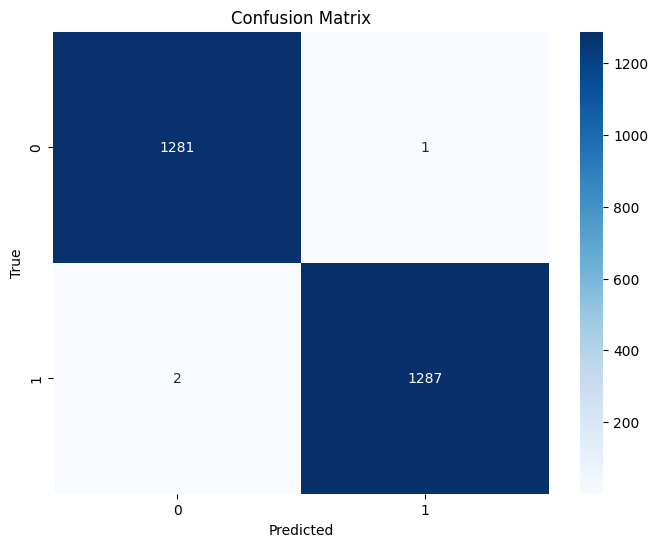

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate predictions on validation data
y_true = val_labels  # Actual labels
y_pred_prob = model.predict(val_ds)  # Model outputs probabilities
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary (0 or 1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [48]:
# Evaluate on validation set
model.evaluate(val_ds)

# Predict on a pair
def verify_pair(img_path1, img_path2):
    img1 = tf.expand_dims(preprocess_image(img_path1), axis=0)
    img2 = tf.expand_dims(preprocess_image(img_path2), axis=0)
    pred = model.predict([img1, img2])[0][0]
    return pred

score = verify_pair("/kaggle/input/monkeypox-skin-lesion-dataset/Fold1/Fold1/Fold1/Test/Monkeypox/M04_01.jpg", "/kaggle/input/monkeypox-skin-lesion-dataset/Fold1/Fold1/Fold1/Test/Monkeypox/M39_01.jpg")
print("Similarity Score:", score)

81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 186ms/step - accuracy: 0.9989 - loss: 0.0053
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Similarity Score: 0.012431516


/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


In [44]:
from sklearn.metrics import classification_report

# After predicting
y_true = val_labels
y_pred = model.predict(val_ds)
y_pred = (y_pred > 0.5).astype(int)
print(classification_report(y_true, y_pred))

81/81 ━━━━━━━━━━━━━━━━━━━━ 25s 242ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1282
           1       1.00      1.00      1.00      1289

    accuracy                           1.00      2571
   macro avg       1.00      1.00      1.00      2571
weighted avg       1.00      1.00      1.00      2571

